# Shor's Integer Factoring Algorithm

This kata introduces you to Shors's integer factoring algorithm - one of the fundamental algorithms in quantum computing.

**This kata covers the following topics:**

- Integer factoring problem and its connection to period finding problem
- Implementing simplified variants of Shor's algorithm for factoring $15$ and $21$ in Workbench
- Practical considerations for implementing Shor's algorithm in general case

**What you should know to start working on this kata:**

- Basic quantum gates and measurements
- Basics of reversible computing
- Quantum Fourier transform and quantum phase estimation

In [1]:
# Execute this cell to prepare the test infrastructure
from psiqdk.workbench import Qubits
from test_ShorsFactoring import problem

## The integer factoring problem

The problem solved by Shor's algorithm is the *integer factoring problem* that can be formulated as follows:
Given an integer number $N$, find its decomposition into a product of integer factors.

> This problem poses significant interest in the context of cryptography. The security of the RSA public-key cryptosystem relies on the assumption that finding the prime factors of a very large number $N = pq$ is computationally infeasible. If a quantum computer provides a way to factor huge integers efficiently, we need to understand that and take action accordingly. The research on cryptosystems that are secure from quantum computers is called *post-quantum cryptography*.

### Classical solution

It is, of course, possible to solve integer factoring problem classically. The simplest method is trial division: check whether the number $N$ is divisible by $2, 3, 5, 7, 11$, and so on, trying each prime number in turn. More sophisticated classical algorithms are more efficient, but even they don't allow factoring huge numbers in reasonable time.

## Period finding problem

Integer factoring problem turns out to be related to another task called *period finding problem* (sometimes *order finding problem*). It is formulated as follows.

You are given two coprime numbers, $N$ (the number we want to factor) and $2 \le a < N$. *Coprime* means that the numbers don't have any common divisors greater than $1$, that is, their *greatest common divisor* is $1$: 

$$\textrm{gcd}(a, N) = 1$$

For example, for $N = 15$, the list of potential numbers $a$ that are coprime with $N$ is $2, 4, 7, 8, 11, 13, 14$ (that is, all numbers between $2$ and $15$ not divisible by $3$ or $5$).

Next, we consider the sequence of numbers $a^k \textrm{ mod } N$ ($\textrm{mod }N$ is operator of calculating remainder of division by $N$) for different non-negative integers $k$. Here is the beginning of this sequence for $N = 15$ and $a = 2$:

| k   | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | ... |
| --- | - | - | - | - | - | - | - | - | - | - | -- | -- | --- |
| $2^k$ | 1 | 2 | 4 | 8 | 16 | 32 | 64 | 128 | 256 | 512 | 1024 | 2048 | ... |
| $2^k \textrm{ mod } 15$ | 1 | 2 | 4 | 8 | 1 | 2 | 4 | 8 | 1 | 2 | 4 | 8 | ... |

You can see that this sequence is periodic: it has only four distinct elements, and after that it starts repeating itself. The period of this sequence is $4$ - the number of elements between repeats. This sequence will always be periodic for all values of $N$ and $a$: since its elements are remainders of division by $N$, they can only take values from $0$ to $N - 1$, and once an element repeats, all the elements after it will repeat as well.

The task of the period finding problem is: given the number $N$ and $a$, find the period of the sequence $a^k \textrm{ mod } N$.

> How is this problem related to integer factoring? It turns out that if $p$ is the period of this sequence, then numbers $\textrm{gcd}(N, a^{p/2} - 1)$ and $\textrm{gcd}(N, a^{p/2} + 1)$ might be factors of $N$. For our example $N = 15$, $a = 2$, and $p = 4$, $a^{p/2} - 1 = 2^2 - 1 = 3$ and $a^{p/2} + 1 = 2^2 + 1 = 5$ are exactly the factors of $15$!

## Problem 1. Find the function period classically

**Inputs:** 

1. An integer $N \ge 15$.
2. An integer $a$ ($2 \le a < N$) coprime to $N$.

**Goal:** 
Find the period of the sequence $a^k \textrm{ mod } N$.

In [ ]:
@problem
def find_period_classical(n: int, a: int) -> int:
    # Write your code here
    ...

## Factoring 15

Before discussing Shor's algorithm in general, we'll walk through a very small case of the problem and its solution: factoring $15$ using the coprime $a = 2$. This case has several advantages that greatly simplify the algorithm implementation:

* $15$ is the smallest odd number that has two different factors and thus can be factored using this approach.
* The implementation uses relatively few qubits, so it can be simulated on a state vector simulator, and we can follow the evolution of the program state easily.
* Computing $2^k \textrm{ mod } 15$ that we'll need to implement as part of the algorithm is much more straightforward than the general-case exponentiation.

In the next three tasks, we'll implement the building blocks of the algorithm - the steps we'll need to compute $2^k \textrm{ mod } 15$.

## Problem 2. Multiply number by 2 modulo 15

**Input:** 
A Qubits register of length $4$ in an arbitrary superposition state $\ket{x}$ (the input register $\ket{x}$).

**Goal:** 
Compute the value $2x \textrm{ mod } 15$ in-place (updating the state of the register to hold the result) for all values of $x$ between $0$ and $14$, inclusive. If the value of $x$ is $15$, leave it unchanged.

> When implementing in-place modular multiplication as a unitary quantum operation, we need to first modify its definition to make it a reversible classical function. Otherwise, two different basis states ($\ket{0}$ and $\ket{15}$) will need to be mapped to the same basis state $\ket{0}$, and this is impossible to do using a unitary transformation. Usually, the definition of modular multiplication by $k$ modulo $N$ is modified as follows: 
> * $x \rightarrow kx \textrm{ mod } N$ if $0 \le x < N$
> * $x \rightarrow x$ if $x \ge N$

In [ ]:
@problem
def multiply_by_2_mod_15(x: Qubits) -> None:
    # Write your code here
    ...

## Problem 3. Multiply number by 4 modulo 15

**Input:** 
A Qubits register of length $4$ in an arbitrary superposition state $\ket{x}$ (the input register $\ket{x}$).

**Goal:** 
Compute the value $4x \textrm{ mod } 15$ in-place (updating the state of the register to hold the result) for all values of $x$ between $0$ and $14$, inclusive. If the value of $x$ is $15$, leave it unchanged.

In [ ]:
@problem
def multiply_by_4_mod_15(x: Qubits) -> None:
    # Write your code here
    ...

## Analyze: Multiply number by 16 modulo 15

The next building block we need to implement modular multiplication is multiplying a number by $2^4 = 16$. How can you do that? Do you need to write code to do that?

<details>
<summary><b>Solution</b></summary>

Remember that we're doing multiplication modulo $15$ rather than regular multiplication. This allows us to simplify our computation quite a bit!

$$16 \cdot x \textrm{ mod } 15 = (16 \textrm{ mod } 15) \cdot x \textrm{ mod } 15 = x \textrm{ mod } 15 = x$$

The corresponding unitary transformation is just an identity, so we don't even need to write code for it!

You can use the same logic to see that multiplication by $2^2^{m}$ for $m \ge 2$ is an identity as well.
</details>

## Problem 4. Multiply number by $2^k$ modulo 15

**Inputs:** 
1. A Qubits register of length $4$ in an arbitrary superposition state $\ket{x}$ (the input register $\ket{x}$).
2. An integer $k \ge 0$.

**Goal:** 
Compute the value $2^k \cdot x \textrm{ mod } 15$ in-place (updating the state of the register to hold the result) for all values of $x$ between $0$ and $14$, inclusive. If the value of $x$ is $15$, leave it unchanged.

In [ ]:
@problem
def multiply_by_2k_mod_15(x: Qubits, k: int) -> None:
    # Write your code here
    ...

## High-level outline of Shor's algorithm for $N = 15$

The high-level outline of the algorithm that we will implement in a moment looks as follows:

1. Allocate two qubit registers, `k` to represent the powers between $0$ and $15$ and `a_k` to represent the values $2^k$ for each $k$. We'll need $4$ bits to represent each of them, since the values in both will range from $0$ to $15$.
2. Initialize these registers.  
   We'll need to consider all powers, so `k` is just a superposition of all basis states: $\frac14 \sum_{k = 0}^{15} \ket{k}$.  
   We will compute the powers $2^k$ by multiplying the register `a_k` by $2^1$, $2^2$, $2^4$, and so on, so we need to start with it in the $\ket{1}$ state.  
   At this point, the state of the system is 
   $$\frac14 \sum_{k = 0}^{15} \ket{k}_{k} \otimes \ket{1}_{a_k}$$
3. Calculate the values $2^k \textrm{ mod } 15$ in the register `a_k`. We'll do it in several steps:

   3.1. Compute the values $2^{k \textrm{ mod } 2} \textrm{ mod } 15$ by multiplying `a_k` by $2$ conditioned on the least significant bit of the register $k$.
   3.2. Compute the values $2^{k \textrm{ mod } 4} \textrm{ mod } 15$ by multiplying `a_k` by $4$ conditioned on the second least significant bit of the register $k$.
   3.3. We would normally continue multiplying `a_k` by $16$, $256$, and so on, conditioned on increasingly more significant bits of register $k$. However, we've established that those multiplications are equivalent to identities, so we don't need to implement them in the code.

   At this point, the state of the system is 
   $$\frac14 \sum_{k = 0}^{15} \ket{k}_{k} \otimes \ket{2^k \textrm{ mod } 15}_{a_k}$$

4. Now, we have distinct values from $0$ to $15$ in the register `k`, and a nice periodic signal in the register `a_k` that loops through the values $1, 2, 4, 8$. If we rewrite the state to group the terms with the same value of $a_k$, we'll get the following expression:

   $$\tfrac14 \ket{1}_{a_k} (\ket{0} + \ket{4} + \ket{8} + \ket{12})_{k} + $$
   $$\tfrac14 \ket{2}_{a_k} (\ket{1} + \ket{5} + \ket{9} + \ket{13})_{k} + $$
   $$\tfrac14 \ket{4}_{a_k} (\ket{2} + \ket{6} + \ket{10} + \ket{14})_{k} + $$
   $$\tfrac14 \ket{8}_{a_k} (\ket{3} + \ket{7} + \ket{11} + \ket{15})_{k}$$

   We know a tool suitable for analyzing periodic signals: it's quantum Fourier transform. Indeed, we can extract information about the period from the register `k` by applying inverse quantum Fourier transform to it and then measuring it!

## Demo: factoring 15

The following code snippet shows how to implement Shor's algorithm for factoring $15$ in Workbench. It goes through the steps described above and prints the state of the system after every step.

Initial state of the system
|a^k|k>
|1|0>    0.250000+0.000000j
|1|1>    0.250000+0.000000j
|1|2>    0.250000+0.000000j
|1|3>    0.250000+0.000000j
|1|4>    0.250000+0.000000j
|1|5>    0.250000+0.000000j
|1|6>    0.250000+0.000000j
|1|7>    0.250000+0.000000j
|1|8>    0.250000+0.000000j
|1|9>    0.250000+0.000000j
|1|10>    0.250000+0.000000j
|1|11>    0.250000+0.000000j
|1|12>    0.250000+0.000000j
|1|13>    0.250000+0.000000j
|1|14>    0.250000+0.000000j
|1|15>    0.250000+0.000000j
a_k = 2^(k mod 2)
|a^k|k>
|1|0>    0.250000+0.000000j
|2|1>    0.250000+0.000000j
|1|2>    0.250000+0.000000j
|2|3>    0.250000+0.000000j
|1|4>    0.250000+0.000000j
|2|5>    0.250000+0.000000j
|1|6>    0.250000+0.000000j
|2|7>    0.250000+0.000000j
|1|8>    0.250000+0.000000j
|2|9>    0.250000+0.000000j
|1|10>    0.250000+0.000000j
|2|11>    0.250000+0.000000j
|1|12>    0.250000+0.000000j
|2|13>    0.250000+0.000000j
|1|14>    0.250000+0.000000j
|2|15>    0.250000+0.000000j
a_k = 2^(k mod 4) (mod 15)
|a^

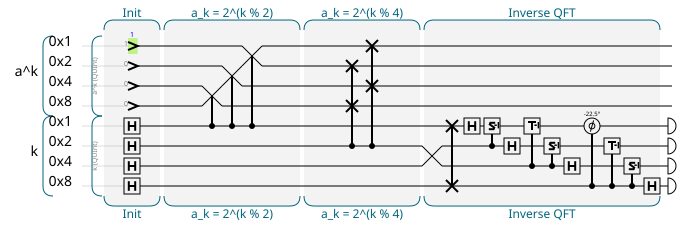

In [ ]:
from psiqdk.workbench import QPU, QUInt

def Shor15(qpu: QPU, verbose: bool = False) -> int:
    # Hardcode the number of bits we need to represent the number and the period both
    n_bits = 4

    qpu.reset(num_qubits=2 * n_bits)
    # Register we'll use to represent a^k
    a_k = QUInt(n_bits, "a^k", qpu)
    # Register we'll use to represent the power k
    k = QUInt(n_bits, "k", qpu)

    # Prepare the initial states of the registers:
    # A superposition of all possible powers in k
    qpu.label("Init")
    k.had()
    # |1⟩ in a_k
    a_k.write(1)

    if verbose:
        print("Initial state of the system")
        qpu.print_state_vector()

    # Multiply a_k a by 2 modulo 15, conditioned on the least significant bit of k
    qpu.label("a_k = 2^(k % 2)")
    for ind in range(n_bits - 1, 0, -1):
        a_k[ind].swap(a_k[ind - 1], k[0])

    if verbose:
        print("a_k = 2^(k mod 2)")
        qpu.print_state_vector()

    # Multiply a_k by 4 modulo 15, conditioned on the second least significant bit of k
    qpu.label("a_k = 2^(k % 4)")
    for ind in range(n_bits - 1, 1, -1):
        a_k[ind].swap(a_k[ind - 2], k[1])

    if verbose:
        print("a_k = 2^(k mod 4) (mod 15)")
        qpu.print_state_vector()

    # Multiplying a_k by 16 and by 256 modulo 15 is identity, so it has no code representation.
    # You can see that a^k register indeed holds 2^k mod 15, just like in our table!

    # Apply inverse QFT to register k
    qpu.label("Inverse QFT")
    k.QFT(dagger=True)
    qpu.label("")

    if verbose:
        print("State after QFT")
        qpu.print_state_vector()

    return k.read()
    
qpu = QPU()
measurement_result = Shor15(qpu, verbose=True)
print(f"Result = {measurement_result}")
qpu.draw()

You can see that after applying QFT, measuring the register `k` can yield one of the four results: $0$, $4$, $8$, or $12$. What are their respective frequencies? Let's run our program multiple times to gather the statistics.

In [6]:
def gather_statistics(shor: callable):
    qpu = QPU()
    # Run the algorithm a thousand times and count the number of different measurement outcomes
    res = {}
    for _ in range(1000):
        measurement_result = shor(qpu)
        res[measurement_result] = res.get(measurement_result, 0) + 1

    # Print the results, sorted by value
    res_view = [(val, freq) for val, freq in res.items()]
    res_view.sort()
    for val, freq in res_view:
        print(f"{val} - {freq}")

    return res

gather_statistics(Shor15)

0 - 261
4 - 226
8 - 249
12 - 264


{12: 264, 8: 249, 4: 226, 0: 261}

Each of the measurement outcomes can be produced with roughly equal probability. If the measurement outcome is $0$, we can't get any information from it, but the other outcomes look promising. How can we interpret them and get the information about the period from them? It is tempting to say that the smallest non-zero measurement outcome is the period of the function - after all, it matches the period that we got classically! However, let's not be hasty and take a look at one more example - $N = 21$.

## Demo: factoring 21

Let's construct the same sequence of numbers $a^k \textrm{ mod } N$ for $N = 21$ and coprime $a = 2$:

|  k  | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | ... |
| --- | - | - | - | - | - | - | - | - | - | - | -- | -- | -- | --- |
| $2^k$ | 1 | 2 | 4 | 8 | 16 | 32 | 64 | 128 | 256 | 512 | 1024 | 2048 | 4096 | ... |
| $2^k \textrm{ mod } 21$ | 1 | 2 | 4 | 8 | 16 | 11 | 1 | 2 | 4 | 8 | 16 | 11 | 1 | ... |

We can see that the period of this sequence is $p = 6$.

> To get the factors of the number, we again calculate $a^{p/2} - 1 = 2^3 - 1 = 7$ and $a^{p/2} + 1 = 2^3 + 1 = 9$. The first value is the factor of $21$ itself, and for the second one $\textrm{gcd}(9, 21) = 3$ gives us the other factor. 

Now, let's simulate Shor's algorithm to see the final state of the program before measurements and the possible measurement outcomes.

> In the case of $N = 15$, we could take advantage of the fact that $16x = x \textrm{ mod }15$ to greatly simplify the implementation of modular multiplication. Unfortunately, the same simplification doesn't work for $N = 21$; we would need to put more effort into implementing proper multiplication modulo $21$. 
>
> However, right now we're interested in the last step of the algorithm: assuming that we prepared the right state in the register `a_k` for each value in the register `k`, how does QFT change it, and what are the measurement outcomes and their frequencies? To explore that part of the algorithm, we can take a different shortcut: start by preparing the following state directly, without arriving to it via modular multiplication:
>
> $$\frac1{\sqrt{32}} \sum_{k = 0}^{31} \ket{k}_{k} \otimes \ket{2^k \textrm{ mod } 21}_{a_k}$$
> 
> The easiest way to prepare this state is to treat it as a data loading problem: prepare the register `k` in the state that is the superposition of all possible powers and then use `SelectNaive` Qubrick from Workbench Algorithms to load classical data into the register `a_k` using the register `k` as the index.
>
> After that, we can resume the normal flow of the algorithm: apply QFT and gather measurement statistics.

a_k = 2^k (mod 21)
|a^k|k>
|1|0>    0.176777+0.000000j
|2|1>    0.176777+0.000000j
|4|2>    0.176777+0.000000j
|8|3>    0.176777+0.000000j
|16|4>    0.176777+0.000000j
|11|5>    0.176777+0.000000j
|1|6>    0.176777+0.000000j
|2|7>    0.176777+0.000000j
|4|8>    0.176777+0.000000j
|8|9>    0.176777+0.000000j
|16|10>    0.176777+0.000000j
|11|11>    0.176777+0.000000j
|1|12>    0.176777+0.000000j
|2|13>    0.176777+0.000000j
|4|14>    0.176777+0.000000j
|8|15>    0.176777+0.000000j
|16|16>    0.176777+0.000000j
|11|17>    0.176777+0.000000j
|1|18>    0.176777+0.000000j
|2|19>    0.176777+0.000000j
|4|20>    0.176777+0.000000j
|8|21>    0.176777+0.000000j
|16|22>    0.176777+0.000000j
|11|23>    0.176777+0.000000j
|1|24>    0.176777+0.000000j
|2|25>    0.176777+0.000000j
|4|26>    0.176777+0.000000j
|8|27>    0.176777+0.000000j
|16|28>    0.176777+0.000000j
|11|29>    0.176777+0.000000j
|1|30>    0.176777+0.000000j
|2|31>    0.176777+0.000000j
State after QFT
|a^k|k>
|1|0>    0.187500+0.0

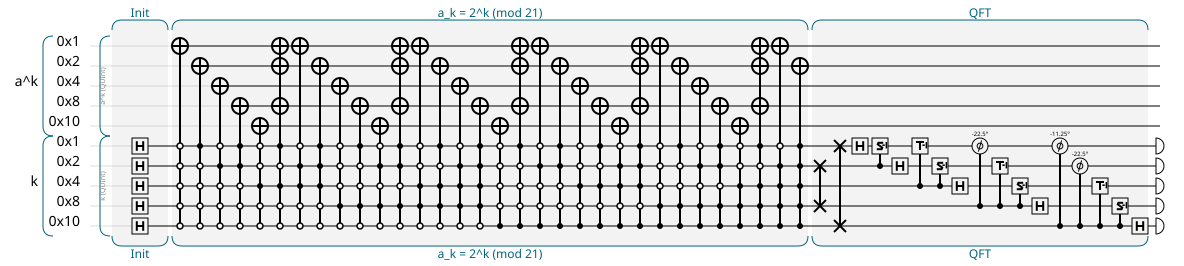

In [7]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.algorithms import SelectNaive

def Shor21(qpu: QPU, verbose: bool = False) -> int:
    # Hardcode the numbers of bits we need to represent the number and the period
    n_bits = 5

    qpu.reset(num_qubits=2 * n_bits)
    # Register we'll use to represent a^k
    a_k = QUInt(n_bits, "a^k", qpu)
    # Register we'll use to represent the power k
    k = QUInt(n_bits, "k", qpu)

    # Prepare the initial state of the register k: a superposition of all possible powers
    qpu.label("Init")
    k.had()
    # Don't initialize a_k with |1⟩ - data loading will take care of the register a_k

    # Load the data from the table using data loading Qubrick
    powers_classical = [(2 ** k) % 21 for k in range(32)]
    select = SelectNaive()
    qpu.label("a_k = 2^k (mod 21)")
    select.compute(index_reg=k, target_reg=a_k, data=powers_classical)

    if verbose:
        print("a_k = 2^k (mod 21)")
        qpu.print_state_vector()

    # Apply QFT to register k
    qpu.label("QFT")
    k.QFT(dagger=True)
    qpu.label("")

    if verbose:
        print("State after QFT")
        qpu.print_state_vector()

    return k.read()
    
qpu = QPU()
measurement_result = Shor21(qpu, verbose=True)
print(f"Result = {measurement_result} (fixed point = {measurement_result / (2 ** 5)})")
qpu.draw()

This time, the system state after QFT is not as neat as it was for $N = 15$. The register `k` takes every possible value between $0$ and $31$ for each of the values $1, 2, 4, 8, 11, 16$ of the register `a_k`, with varying amplitudes. However, let's see what the measurement probabilities look like for this state.

In [8]:
res_21 = gather_statistics(Shor21)

0 - 161
3 - 3
4 - 9
5 - 126
6 - 31
7 - 2
8 - 2
9 - 7
10 - 23
11 - 120
12 - 9
13 - 3
14 - 1
15 - 2
16 - 162
17 - 2
18 - 3
19 - 4
20 - 11
21 - 122
22 - 24
23 - 5
24 - 4
25 - 3
26 - 36
27 - 113
28 - 7
29 - 3
30 - 2


You can see that while all measurement outcomes are possible, some of them are much more probable than the others. If we plot the histogram of the frequencies of the measurement results, we'll see significant peaks at outcomes $0$, $5$, $11$, $16$, $21$, and $27$. The distance between the consecutive peaks is either $5$ or $6$.

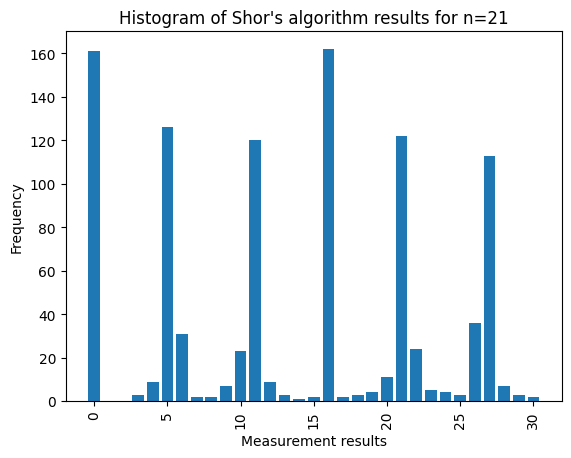

In [9]:
import matplotlib.pyplot as plt

def plot_results(results):
    labels, values = zip(*sorted(results.items()))

    plt.bar(labels, values)
    plt.xlabel('Measurement results')
    plt.xticks(rotation=90)
    plt.ylabel('Frequency')
    plt.title("Histogram of Shor's algorithm results for n=21")
    plt.show()

plot_results(res_21)

This plot gives us a better picture of the relationship between the measurement outcomes and the function period: the period of the function is not the distance between adjacent peaks, but their total number. (For $N = 15$ the number of peaks was $4$.)

Now, let's switch gears and talk about the math behind Shor's algorithm, which will give us a different perspective on the measurement outcomes and their analysis, as well as the challenges of applying Shor's algorithm in practice.

## Shor's algorithm as a phase estimation problem

Let's fix our choice of integers $N$ and $a$, and define $n = \lceil \log_2 N \rceil$ as the number of bits in the binary notation of $N$. We'll denote the period of the function we're looking for as $p$.

We define a unitary transformation "modular multiplication by $a$" that acts on $n$ qubits based on its effect on $n$-qubit basis states $\ket{x}$:

$$U\ket{x} = 
\begin{cases} 
    \ket{a \cdot x \textrm{ mod } N}, 0 \le x \le N - 1, \\ 
    \ket{x}, N \le x \le 2^n - 1
\end{cases}$$

This transformation is indeed unitary, since it is a permutation - different basis states are mapped into different basis states. (Since $a$ and $N$ are coprime, there are no collisions between $ax \textrm{ mod } N$ values for different $x$.)

Now, let's consider the following quantum state:

$$\ket{\psi_1} = \frac{1}{\sqrt{p}} \sum_{k = 0}^{p-1} e^{-2\pi i \left( \frac{1}{p} \right) k}  \ket{a^k \textrm{ mod } N}$$

If we apply the transformation $U$ to this state, we'll get the following expression, with each power of $a$ increased by $1$:

$$U \ket{\psi_1} = \frac{1}{\sqrt{p}} \sum_{k = 0}^{p-1} e^{-2\pi i \left( \frac{1}{p} \right) k}  \ket{a^{\color{red}{k + 1}} \textrm{ mod } N}$$

Now, let's rewrite the amplitude of each basis state as a product of two terms, one that matches the power of $a$ in the corresponding basis state (same as we had in the $\ket{\psi_1}$) and a multiplier that is the same for all terms. We can then take the shared multiplier outside the sum:

$$U \ket{\psi_1} = \frac{1}{\sqrt{p}} \sum_{k = 0}^{p-1} e^{\color{red}{2\pi i \left( \frac{1}{p} \right)}} e^{-2\pi i \left( \frac{1}{p} \right) \color{red}{(k + 1)}}  \ket{a^{\color{red}{k + 1}} \textrm{ mod } N} = \\
= e^{2\pi i \left( \frac{1}{p} \right)} \frac{1}{\sqrt{p}} \sum_{k = 0}^{p-1} e^{-2\pi i \left( \frac{1}{p} \right) (k + 1)}  \ket{a^{k + 1} \textrm{ mod } N}$$

Next, we simplify the last term of the sum (the one for $k = p-1$), using the fact that $p$ is the period of the function and thus $a^p = 1 \textrm{ mod } N$:

$$e^{-2\pi i \left( \frac{1}{p} \right) ((p-1) + 1)} = e^{-2\pi i \left( \frac{1}{p} \right) p} = e^{-2\pi i} = 1 = e^0$$

$$\ket{a^{(p-1) + 1} \textrm{ mod } N} = \ket{a^p \textrm{ mod } N} = \ket{1 \textrm{ mod } N} = \ket{a^0 \textrm{ mod } N}$$

With this simplification, we can reorganize the sum as follows:

$$\sum_{k = 0}^{p-1} e^{-2\pi i \left( \frac{1}{p} \right) (k + 1)}  \ket{a^{k + 1} \textrm{ mod } N} = \\

= \sum_{\color{red}{k = 0}}^{\color{red}{p-2}} e^{-2\pi i \left( \frac{1}{p} \right) \color{red}{(k + 1)}}  \ket{a^{\color{red}{k + 1}} \textrm{ mod } N} + 
e^{-2\pi i \left( \frac{1}{p} \right) \color{red}{((p-1) + 1)}}  \ket{a^{\color{red}{(p-1) + 1}} \textrm{ mod } N} = \\

= \sum_{\color{red}{j = 1}}^{\color{red}{p-1}} e^{-2\pi i \left( \frac{1}{p} \right) \color{red}{j}}  \ket{a^{\color{red}{j}} \textrm{ mod } N} +
e^{-2\pi i \left( \frac{1}{p} \right) \color{red}{0}}  \ket{a^{\color{red}{0}} \textrm{ mod } N} = \\

= \sum_{\color{red}{j = 0}}^{\color{red}{p-1}} e^{-2\pi i \left( \frac{1}{p} \right) \color{red}{j}}  \ket{a^{\color{red}{j}} \textrm{ mod } N} = \\ 

= \ket{\psi_1}$$

Finally, we combine the two parts to get the result:

$$U \ket{\psi_1} = e^{2\pi i \left( \frac{1}{p} \right)} \ket{\psi_1}$$

We see that the state $\ket{\psi_1}$ is an eigenstate of the unitary $U$ with an eigenvalue $e^{2\pi i \left( \frac{1}{p} \right)}$ and matching eigenphase $\frac{1}{p}$. This means that we can apply phase estimation algorithm to find $\frac{1}{p}$ and derive the period $p$ from this value!

### What do we need to apply phase estimation to integer factoring?

Phase estimation algorithm requires two main components:

1. An efficient implementation of the unitary - in this case, modular multiplication by $a$ - and its powers - modular multiplication by $a^2$, $a^4$, $a^8$, and so on.  
   To implement modular multiplication by $2$, we used the fact that $16x = x \textrm{ mod }15$, which, in turn, relied on our knowledge of the period of the function we're seeking to analyze! In general, this can be done using reversible arithmetic tools. (This is similar to implementing the oracle for Grover's search: you have to implement it based on the definition of the function, not on the upfront knowledge of the answer!) However, the resulting circuit is not a trivial one like it is for factoring $15$.

2. An efficient method to prepare the eigenstate $\ket{\psi_1}$.  
   This state not only has a complicated form, it is expressed via the period $p$ - which we don't know when implementing the algorithm.  
   
Fortunately, quantum phase estimation works not only for input eigenstates but also for superpositions of different eigenstates. We can define $p$ states similar to $\ket{\psi_1}$, differing only in the expression in the exponent:

$$\ket{\psi_{\color{red}{1}}} = \frac{1}{\sqrt{p}} \sum_{k = 0}^{p-1} e^{-2\pi i \color{red}{\left( \frac{1}{p} \right)} k}  \ket{a^k \textrm{ mod } N} \\

   \vdots \\

   \ket{\psi_{\color{red}{j}}} = \frac{1}{\sqrt{p}} \sum_{k = 0}^{p-1} e^{-2\pi i \color{red}{\left( \frac{j}{p} \right)} k}  \ket{a^k \textrm{ mod } N} \\ 

   \vdots \\

   \ket{\psi_{\color{red}{p}}} = \frac{1}{\sqrt{p}} \sum_{k = 0}^{p-1} e^{-2\pi i \color{red}{\left( \frac{p}{p} \right)} k}  \ket{a^k \textrm{ mod } N}$$

Each state $\ket{\psi_j}$ is an eigenstate of the unitary with an eigenphase $\frac{j}{p}$, and their equal superposition turns out to be $\ket{1}$. If we run phase estimation on the superposition of these states, we'll get a random eigenphase $\frac{j}{p}$, which we can then use to estimate the period $p$.

> You can observe this behavior in the outputs of our demos for factoring $N = 15$ and $N = 21$: the peaks on the histogram of measurement results correspond to the fractions $\frac{j}{4}$ and $\frac{j}{6}$, respectively. For $N = 15$, the fractions can be expressed exactly as fixed-point numbers with four digits of precision, so the measurement results are always the values $\frac{j}{4}$ themselves. For $N = 21$, the fractions $\frac{1}{6}, \frac{2}{6}, \frac{4}{6}$, and $\frac{5}{6}$ don't have an exact binary representation, so the "peaks" that correspond to best approximations of the fractions are surrounds by "tails" that are worse approximations but show up with much lower frequencies.

## Demo: factoring 15 using quantum phase estimation

The following code snippet shows how to factor 15 using the quantum phase estimation approach to Shor's algorithm. It uses two Qubricks: `MultiplyBy2Mod15` implements modular multiplication by $2$ - the unitary on which we run phase estimation - and `QPE` is the library implementation of quantum phase estimation.

Result = 0.5


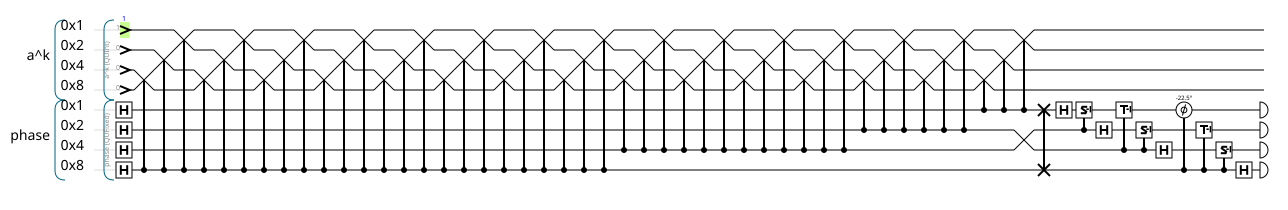

In [ ]:
from psiqdk.workbench import QPU, QUFixed, QUInt, Qubits, Qubrick
from psiqdk.algorithms import QPE

class MultiplyBy2Mod15(Qubrick):
    '''Qubrick that implements transformation x -> 2x mod 15 in-place (with controlled variant support).'''
    def _compute(self, reg: QUInt, ctrl: Qubits | None = None) -> None:
        for ind in range(reg.num_qubits - 1, 0, -1):
            reg[ind].swap(reg[ind - 1], ctrl)


def Shor15_QPE(qpu: QPU) -> float:
    # Hardcode the number of bits we need to represent the number and the period both
    n_bits = 4

    qpu.reset(num_qubits=2 * n_bits)
    # Register we'll use to represent the eigenstate
    a_k = QUInt(n_bits, "a^k", qpu)
    # Register we'll use to store the phase
    phase = QUFixed(n_bits, n_bits, "phase", qpu)

    # Initialize the eigenstate register with |1⟩
    a_k.write(1)

    # Instantiate the QPE Qubrick
    qpe = QPE(bits_of_precision=n_bits, unitary=MultiplyBy2Mod15())

    # Run QPE
    qpe.compute(psi=a_k, phase_reg=phase)

    # Read out the eigenphase
    return phase.read()

qpu = QPU()
measurement_result = Shor15_QPE(qpu)
print(f"Result = {measurement_result}")
qpu.draw()

You can see that the circuit produced by this approach is lengthier. This phase estimation implementation is generic; it doesn't take advantage of the facts that multiplication by $4$ can be implemented as two SWAPs and that multiplication by $16$ and by $256$ is identity. Instead, it computes powers of the given unitary by simply repeating it multiple times. However, the measurement statistics end up the same as in our first implementation:

In [11]:
gather_statistics(Shor15_QPE)

0.0 - 229
0.25 - 269
0.5 - 253
0.75 - 249


{0.75: 249, 0.25: 269, 0.5: 253, 0.0: 229}

## Conclusion

Congratulations! In this kata you learned Shor's algorithm for integer factoring - probably the most famous algorithm in quantum computing. 
Here are a few key concepts to keep in mind:

* Shor's algorithm reduces the problem of integer factoring - finding prime divisors of a number - with the problem of finding the period of a function defined via modular multiplication.
* This problem can be reduced further to finding the eigenphase of an eigenstate of a specific unitary transformation. This is a good example of a practical application of phase estimation algorithms.
* The unitary transformation for the phase estimation algorithm is a reversible implementation of modular multiplication by a constant. This kind of problems is why we need reversible implementations of various arithmetic functions!

> Copyright (c) 2026 PsiQuantum